**Exercise 4.14** Develop a discrete-time mathematical model of two species competing for the same resource, and simulate its behavior.
___

- $K$ : carrying capacity
- $x,y$ : two different predator
- $r_x, r_y$ : growth rate 
- $a$ : effect of y to x
- $b$ : effect of x to y

$$x_t = x_{t-1} + r_x x_{t-1} \left( 1- \frac{x_{t-1} + a y_{t-1}}{K_x} \right) \tag{1}$$
$$y_t = y_{t-1} + r_y y_{t-1} \left( 1- \frac{y_{t-1} + b x_{t-1}}{K_y} \right) \tag{2}$$


# **KR2**

## Base-line

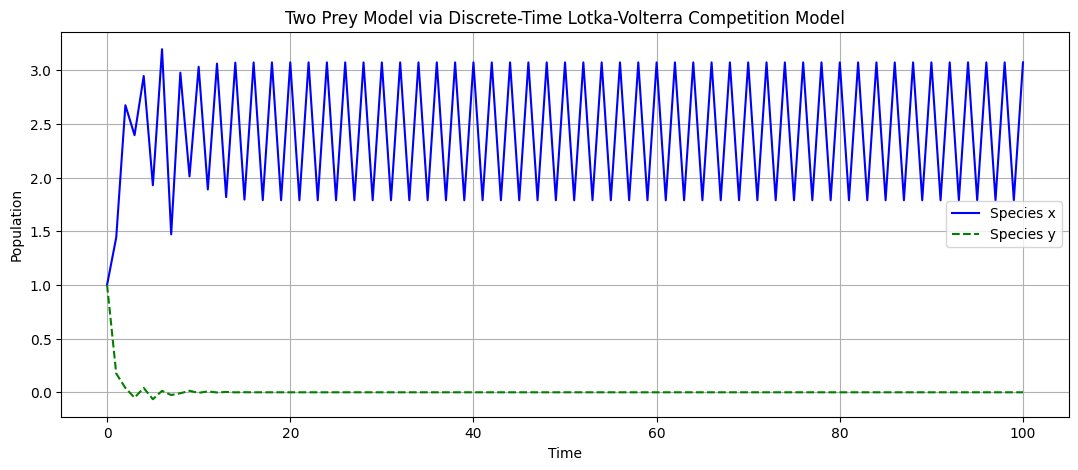

In [4]:
import matplotlib.pyplot as plt

# Initial conditions and simulation length
steps = 100
x0, y0 = 1.0, 1.0

def run_simulation(a, b, r_x, r_y, K_x, K_y):
    x, y = x0, y0
    xresult, yresult = [x], [y]
    for _ in range(steps):
        nextx = x + r_x * x * (1 - (x + a * y) / K_x)
        nexty = y + r_y * y * (1 - (y + b * x) / K_y)
        x, y = nextx, nexty
        xresult.append(x)
        yresult.append(y)
    return xresult, yresult

fig, ax = plt.subplots(figsize=(13, 5))

xres, yres = run_simulation(a=1.1, b=1.7, r_x=2.3, r_y=1.2, K_x=2.6, K_y=1.6)
(line_x,) = ax.plot(xres, 'b-', label='Species x')
(line_y,) = ax.plot(yres, 'g--', label='Species y')
ax.set_title('Two Prey Model via Discrete-Time Lotka-Volterra Competition Model')
ax.set_xlabel('Time')
ax.set_ylabel('Population')
ax.legend()
ax.grid(True)

# **KR3**

## Stable Coexistence (Constant Steady State)

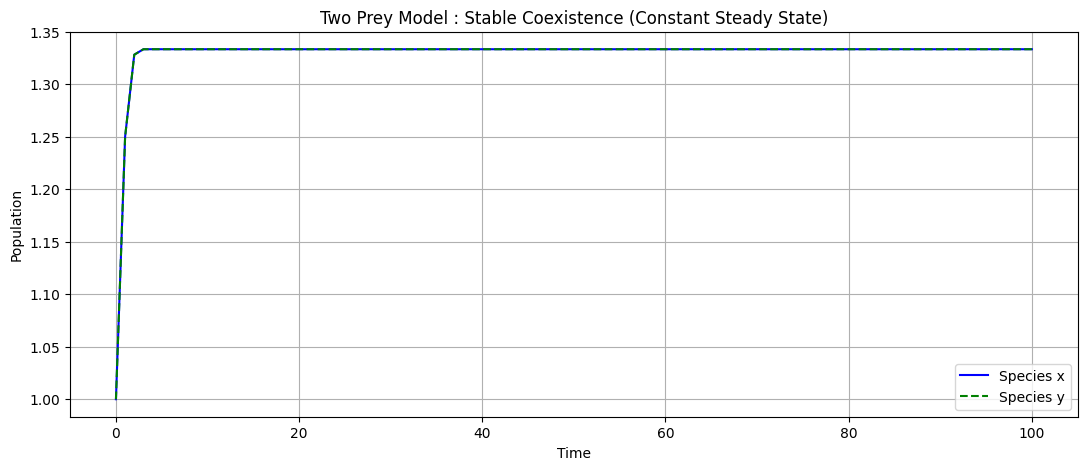

In [8]:
fig, ax = plt.subplots(figsize=(13, 5))

xres, yres = run_simulation(a=0.5, b=0.5, r_x=1.0, r_y=1.0, K_x=2.0, K_y=2.0)
(line_x,) = ax.plot(xres, 'b-', label='Species x')
(line_y,) = ax.plot(yres, 'g--', label='Species y')
ax.set_title('Two Prey Model : Stable Coexistence (Constant Steady State)')
ax.set_xlabel('Time')
ax.set_ylabel('Population')
ax.legend()
ax.grid(True)

## Coexistent Periodic Cycle (Coupled Period-2 Orbit)

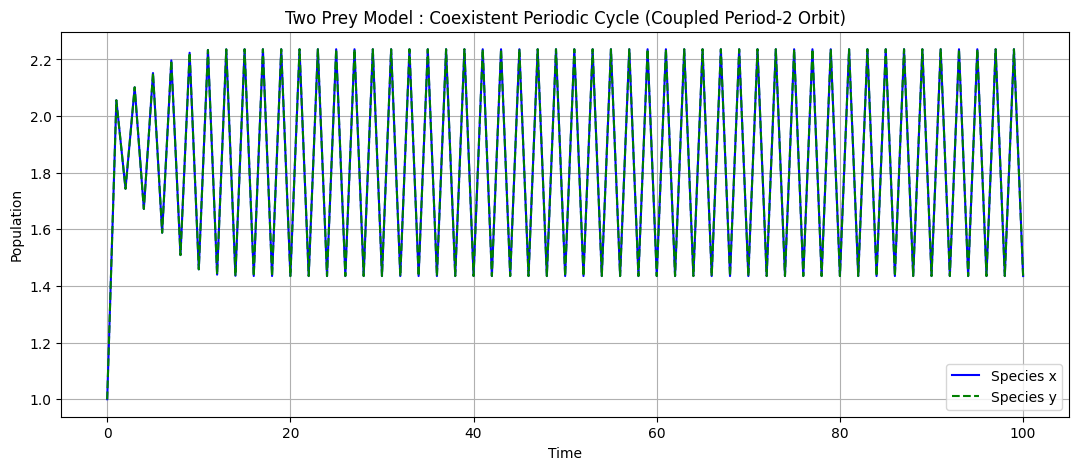

In [9]:
fig, ax = plt.subplots(figsize=(13, 5))

xres, yres = run_simulation(a=0.3, b=0.3, r_x=2.2, r_y=2.2, K_x=2.5, K_y=2.5)
(line_x,) = ax.plot(xres, 'b-', label='Species x')
(line_y,) = ax.plot(yres, 'g--', label='Species y')
ax.set_title('Two Prey Model : Coexistent Periodic Cycle (Coupled Period-2 Orbit)')
ax.set_xlabel('Time')
ax.set_ylabel('Population')
ax.legend()
ax.grid(True)

## Deterministic Chaos

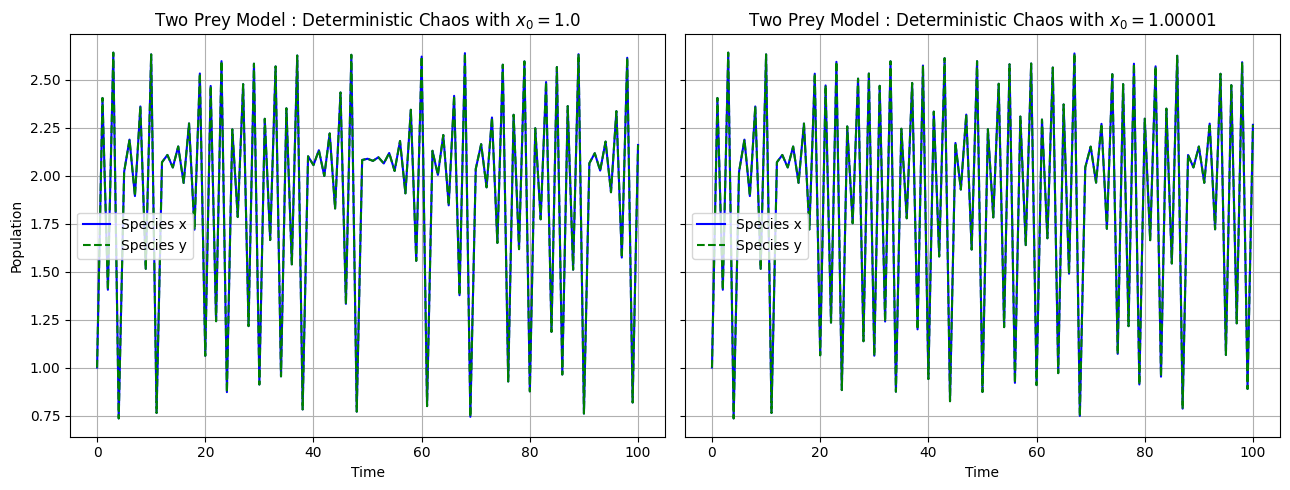

In [21]:
import matplotlib.pyplot as plt

# Initial conditions and simulation length
steps = 100
y0 = 1.0

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, initial_x in zip(axes, (1.0, 1.00001)):
    xres, yres = run_simulation(
        a=0.2, b=0.2, r_x=2.7, r_y=2.7, K_x=2.5, K_y=2.5, x0=initial_x
    )
    ax.plot(xres, 'b-', label='Species x')
    ax.plot(yres, 'g--', label='Species y')
    ax.set_title(f'Two Prey Model : Deterministic Chaos with $x_0 = {initial_x}$')
    ax.set_xlabel('Time')
    ax.grid(True)

axes[0].set_ylabel('Population')
axes[0].legend()
axes[1].legend()
fig.tight_layout()

## Bistability / Priority Effect (Mutual Exclusion)

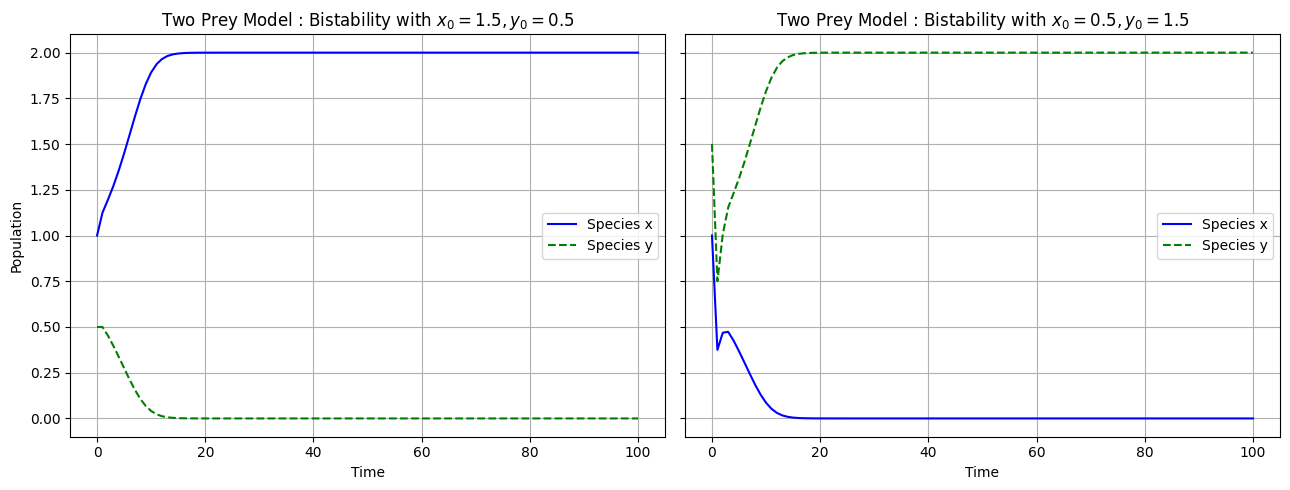

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

initial_conditions = ((1.5, 0.5), (0.5, 1.5))

for ax, (x0, y0) in zip(axes, initial_conditions):
    xres, yres = run_simulation(
        a=1.5, b=1.5, r_x=1.0, r_y=1.0, K_x=2.0, K_y=2.0
    )

    ax.plot(xres, 'b-', label='Species x')
    ax.plot(yres, 'g--', label='Species y')
    ax.set_title(f'Two Prey Model : Bistability with $x_0={x0}, y_0={y0}$')
    ax.set_xlabel('Time')
    ax.grid(True)
    ax.legend()

axes[0].set_ylabel('Population')
fig.tight_layout()

## Periodic Windows inside Chaos (e.g., Period-3 Orbit)

Text(0.98, 0.98, 'Period-3 cycle (x): 0.440, 1.423, 2.699, 0.440, 1.423, 2.699')

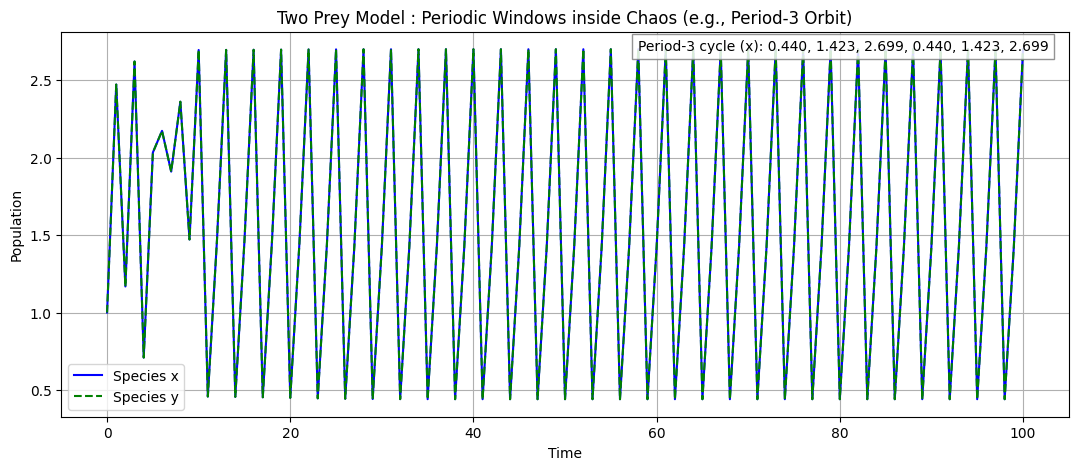

In [59]:
x0, y0 = 1.0, 1.0
steps = 100
fig, ax = plt.subplots(figsize=(13, 5))

xres, yres = run_simulation(a=0.2, b=0.2, r_x=2.83, r_y=2.83, K_x=2.5, K_y=2.5)
(line_x,) = ax.plot(xres, 'b-', label='Species x')
(line_y,) = ax.plot(yres, 'g--', label='Species y')
ax.set_title('Two Prey Model : Periodic Windows inside Chaos (e.g., Period-3 Orbit)')
ax.set_xlabel('Time')
ax.set_ylabel('Population')
ax.legend()
ax.grid(True)

cycle = ", ".join(f"{value:.3f}" for value in xres[-6:])
ax.text(
    0.98, 0.98, f"Period-3 cycle (x): {cycle}",
    transform=ax.transAxes, ha="right", va="top",
    bbox=dict(facecolor="white", alpha=0.85, edgecolor="gray")
)

## Asymmetric / Hybrid Dynamics (Unbalanced Coupling)

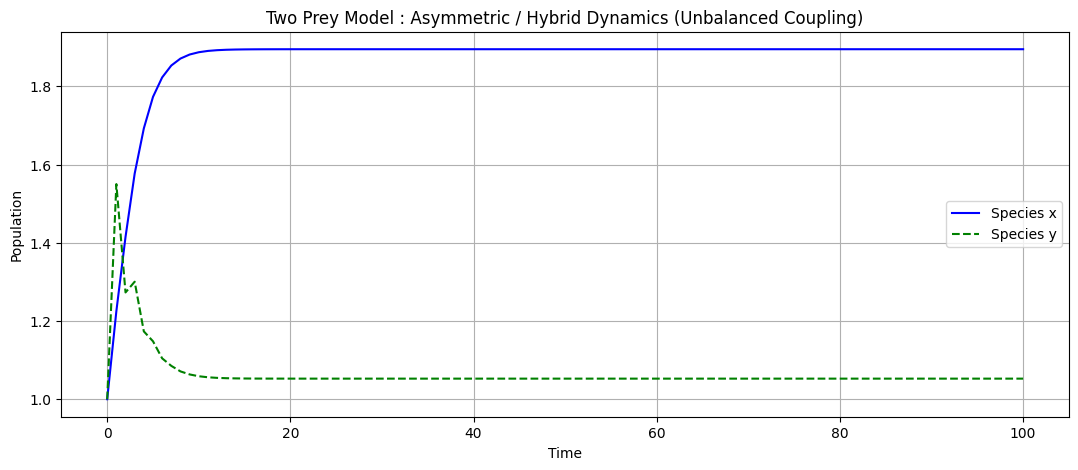

In [63]:
x0, y0 = 1.0, 1.0
steps = 100

fig, ax = plt.subplots(figsize=(13, 5))

xres, yres = run_simulation(a=0.1, b=0.5, r_x=0.5, r_y=2.2, K_x=2.0, K_y=2.0)
(line_x,) = ax.plot(xres, 'b-', label='Species x')
(line_y,) = ax.plot(yres, 'g--', label='Species y')
ax.set_title('Two Prey Model : Asymmetric / Hybrid Dynamics (Unbalanced Coupling)')
ax.set_xlabel('Time')
ax.set_ylabel('Population')
ax.legend()
ax.grid(True)

## Population Collapse / Over-exploitation Extinction

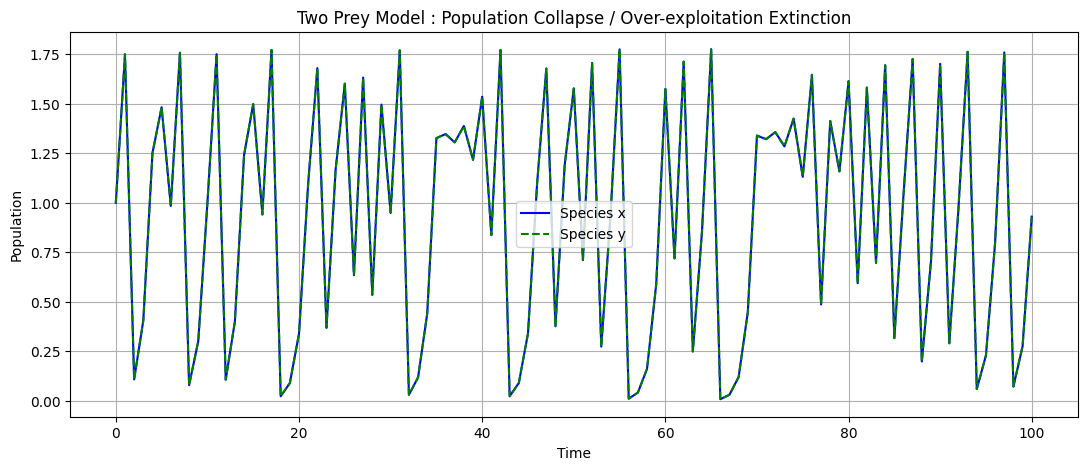

In [84]:
x0, y0 = 1.0, 1.0
steps = 100

fig, ax = plt.subplots(figsize=(13, 5))

xres, yres = run_simulation(a=0.5, b=0.5, r_x=3.001090, r_y=3.001090, K_x=2.0, K_y=2.0)
(line_x,) = ax.plot(xres, 'b-', label='Species x')
(line_y,) = ax.plot(yres, 'g--', label='Species y')
ax.set_title('Two Prey Model : Population Collapse / Over-exploitation Extinction')
ax.set_xlabel('Time')
ax.set_ylabel('Population')
ax.legend()
ax.grid(True)

# KR4: Return Map Characterization 

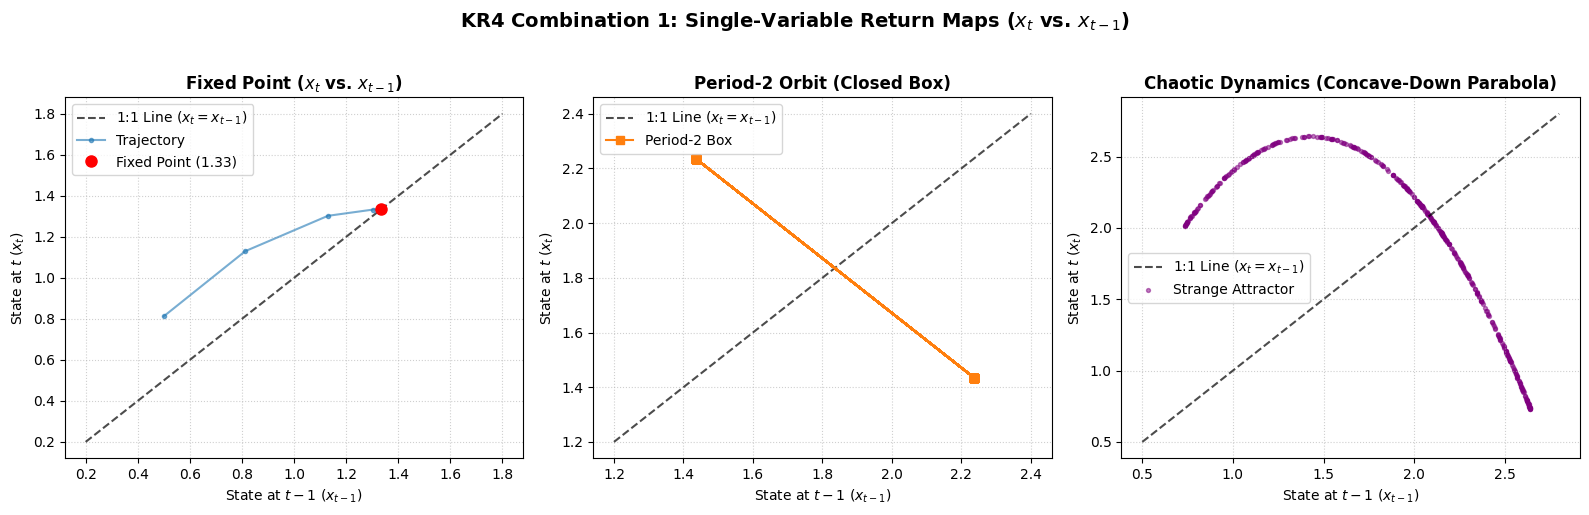

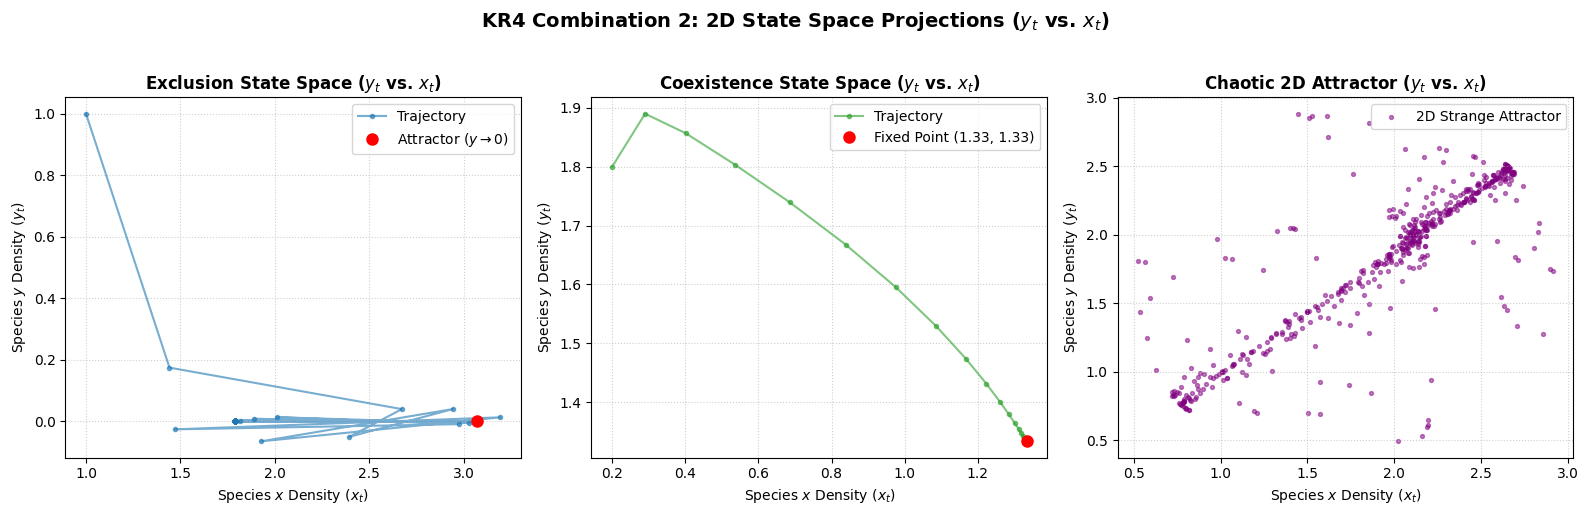

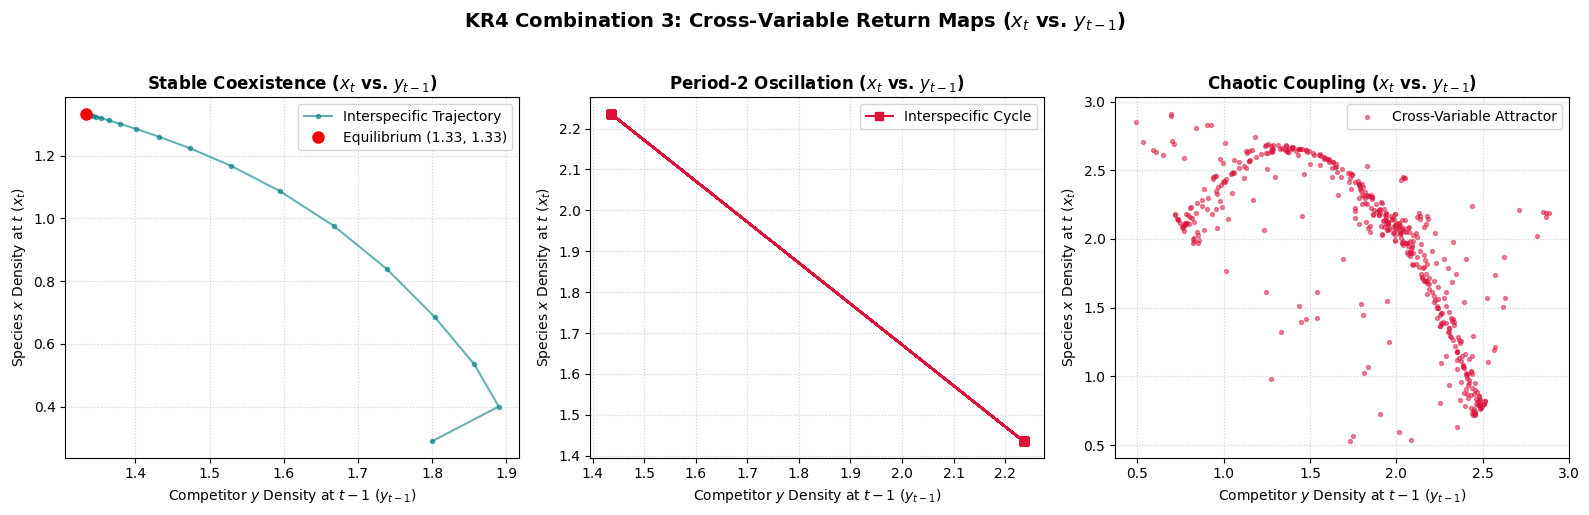

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_two_prey(a, b, rx, ry, Kx, Ky, x0=1.0, y0=1.0, steps=500):
    x = np.zeros(steps + 1)
    y = np.zeros(steps + 1)
    x[0], y[0] = x0, y0
    for t in range(steps):
        x[t+1] = x[t] + rx * x[t] * (1 - (x[t] + a * y[t]) / Kx)
        y[t+1] = y[t] + ry * y[t] * (1 - (y[t] + b * x[t]) / Ky)
    return x, y

def plot_combination_1_single_variable():
    """KR4 Comb 1: Single-Variable Return Maps (x_t vs. x_{t-1})"""
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # --- Panel 1: Fixed Point ---
    x1, _ = simulate_two_prey(a=0.5, b=0.5, rx=1.0, ry=1.0, Kx=2.0, Ky=2.0, x0=0.5, y0=0.5, steps=100)
    grid1 = np.linspace(0.2, 1.8, 200)
    axes[0].plot(grid1, grid1, 'k--', alpha=0.7, label='1:1 Line ($x_t = x_{t-1}$)')
    axes[0].plot(x1[:-1], x1[1:], 'o-', color='tab:blue', alpha=0.6, markersize=3, label='Trajectory')
    axes[0].plot(x1[-1], x1[-1], 'ro', markersize=8, label=f'Fixed Point ({x1[-1]:.2f})')
    axes[0].set_title('Fixed Point ($x_t$ vs. $x_{t-1}$)', fontweight='bold')
    axes[0].set_xlabel('State at $t-1$ ($x_{t-1}$)')
    axes[0].set_ylabel('State at $t$ ($x_t$)')
    axes[0].grid(True, linestyle=':', alpha=0.6)
    axes[0].legend()

    # --- Panel 2: Period-2 Orbit ---
    x2, _ = simulate_two_prey(a=0.3, b=0.3, rx=2.2, ry=2.2, Kx=2.5, Ky=2.5, x0=1.0, y0=1.0, steps=150)
    grid2 = np.linspace(1.2, 2.4, 200)
    axes[1].plot(grid2, grid2, 'k--', alpha=0.7, label='1:1 Line ($x_t = x_{t-1}$)')
    x2_p, x2_n = x2[100:-1], x2[101:]
    axes[1].plot(x2_p, x2_n, 's-', color='tab:orange', markersize=6, lw=1.5, label='Period-2 Box')
    axes[1].set_title('Period-2 Orbit (Closed Box)', fontweight='bold')
    axes[1].set_xlabel('State at $t-1$ ($x_{t-1}$)')
    axes[1].set_ylabel('State at $t$ ($x_t$)')
    axes[1].grid(True, linestyle=':', alpha=0.6)
    axes[1].legend()

    # --- Panel 3: Chaotic Dynamics ---
    x3, _ = simulate_two_prey(a=0.2, b=0.2, rx=2.7, ry=2.7, Kx=2.5, Ky=2.5, x0=1.0, y0=1.0, steps=500)
    grid3 = np.linspace(0.5, 2.8, 200)
    axes[2].plot(grid3, grid3, 'k--', alpha=0.7, label='1:1 Line ($x_t = x_{t-1}$)')
    x3_p, x3_n = x3[100:-1], x3[101:]
    axes[2].scatter(x3_p, x3_n, c='purple', s=8, alpha=0.5, label='Strange Attractor')
    axes[2].set_title('Chaotic Dynamics (Concave-Down Parabola)', fontweight='bold')
    axes[2].set_xlabel('State at $t-1$ ($x_{t-1}$)')
    axes[2].set_ylabel('State at $t$ ($x_t$)')
    axes[2].grid(True, linestyle=':', alpha=0.6)
    axes[2].legend()

    plt.suptitle('KR4 Combination 1: Single-Variable Return Maps ($x_t$ vs. $x_{t-1}$)', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

def plot_combination_2_state_space():
    """KR4 Comb 2: 2D State Space Projections (y_t vs. x_t) with Asymmetric ICs for Chaos"""
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # --- Panel 1: Competitive Exclusion ---
    x1, y1 = simulate_two_prey(a=1.1, b=1.7, rx=2.3, ry=1.2, Kx=2.6, Ky=1.6, x0=1.0, y0=1.0, steps=150)
    axes[0].plot(x1, y1, 'o-', color='tab:blue', alpha=0.6, markersize=3, label='Trajectory')
    axes[0].plot(x1[-1], y1[-1], 'ro', markersize=8, label='Attractor ($y \\to 0$)')
    axes[0].set_title('Exclusion State Space ($y_t$ vs. $x_t$)', fontweight='bold')
    axes[0].set_xlabel('Species $x$ Density ($x_t$)')
    axes[0].set_ylabel('Species $y$ Density ($y_t$)')
    axes[0].grid(True, linestyle=':', alpha=0.6)
    axes[0].legend()

    # --- Panel 2: Coexistence ---
    x2, y2 = simulate_two_prey(a=0.5, b=0.5, rx=1.0, ry=1.0, Kx=2.0, Ky=2.0, x0=0.2, y0=1.8, steps=150)
    axes[1].plot(x2, y2, 'o-', color='tab:green', alpha=0.6, markersize=3, label='Trajectory')
    axes[1].plot(x2[-1], y2[-1], 'ro', markersize=8, label='Fixed Point (1.33, 1.33)')
    axes[1].set_title('Coexistence State Space ($y_t$ vs. $x_t$)', fontweight='bold')
    axes[1].set_xlabel('Species $x$ Density ($x_t$)')
    axes[1].set_ylabel('Species $y$ Density ($y_t$)')
    axes[1].grid(True, linestyle=':', alpha=0.6)
    axes[1].legend()

    # --- Panel 3: Chaotic 2D Strange Attractor (Asymmetric Parameters to avoid y=x line) ---
    # Using asymmetric initial conditions (x0=1.0, y0=0.8) and slightly asymmetric competition (a=0.2, b=0.25, ry=2.65)
    x3, y3 = simulate_two_prey(a=0.2, b=0.25, rx=2.7, ry=2.65, Kx=2.5, Ky=2.5, x0=1.0, y0=0.8, steps=600)
    axes[2].scatter(x3[100:], y3[100:], c='purple', s=8, alpha=0.5, label='2D Strange Attractor')
    axes[2].set_title('Chaotic 2D Attractor ($y_t$ vs. $x_t$)', fontweight='bold')
    axes[2].set_xlabel('Species $x$ Density ($x_t$)')
    axes[2].set_ylabel('Species $y$ Density ($y_t$)')
    axes[2].grid(True, linestyle=':', alpha=0.6)
    axes[2].legend()

    plt.suptitle('KR4 Combination 2: 2D State Space Projections ($y_t$ vs. $x_t$)', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

def plot_combination_3_cross_variable():
    """KR4 Comb 3: Cross-Variable Return Maps (x_t vs. y_{t-1}) with Asymmetric ICs for Chaos"""
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # --- Panel 1: Coexistence ---
    x1, y1 = simulate_two_prey(a=0.5, b=0.5, rx=1.0, ry=1.0, Kx=2.0, Ky=2.0, x0=0.2, y0=1.8, steps=150)
    axes[0].plot(y1[:-1], x1[1:], 'o-', color='teal', alpha=0.6, markersize=3, label='Interspecific Trajectory')
    axes[0].plot(y1[-1], x1[-1], 'ro', markersize=8, label='Equilibrium (1.33, 1.33)')
    axes[0].set_title('Stable Coexistence ($x_t$ vs. $y_{t-1}$)', fontweight='bold')
    axes[0].set_xlabel('Competitor $y$ Density at $t-1$ ($y_{t-1}$)')
    axes[0].set_ylabel('Species $x$ Density at $t$ ($x_t$)')
    axes[0].grid(True, linestyle=':', alpha=0.6)
    axes[0].legend()

    # --- Panel 2: Period-2 Oscillation ---
    x2, y2 = simulate_two_prey(a=0.3, b=0.3, rx=2.2, ry=2.2, Kx=2.5, Ky=2.5, x0=1.0, y0=1.2, steps=150)
    y2_p, x2_n = y2[100:-1], x2[101:]
    axes[1].plot(y2_p, x2_n, 's-', color='crimson', markersize=6, lw=1.5, label='Interspecific Cycle')
    axes[1].set_title('Period-2 Oscillation ($x_t$ vs. $y_{t-1}$)', fontweight='bold')
    axes[1].set_xlabel('Competitor $y$ Density at $t-1$ ($y_{t-1}$)')
    axes[1].set_ylabel('Species $x$ Density at $t$ ($x_t$)')
    axes[1].grid(True, linestyle=':', alpha=0.6)
    axes[1].legend()

    # --- Panel 3: Chaotic Interspecific Coupling ---
    x3, y3 = simulate_two_prey(a=0.2, b=0.25, rx=2.7, ry=2.65, Kx=2.5, Ky=2.5, x0=1.0, y0=0.8, steps=600)
    y3_p, x3_n = y3[100:-1], x3[101:]
    axes[2].scatter(y3_p, x3_n, c='crimson', s=8, alpha=0.5, label='Cross-Variable Attractor')
    axes[2].set_title('Chaotic Coupling ($x_t$ vs. $y_{t-1}$)', fontweight='bold')
    axes[2].set_xlabel('Competitor $y$ Density at $t-1$ ($y_{t-1}$)')
    axes[2].set_ylabel('Species $x$ Density at $t$ ($x_t$)')
    axes[2].grid(True, linestyle=':', alpha=0.6)
    axes[2].legend()

    plt.suptitle('KR4 Combination 3: Cross-Variable Return Maps ($x_t$ vs. $y_{t-1}$)', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    plot_combination_1_single_variable()
    plot_combination_2_state_space()
    plot_combination_3_cross_variable()

# **KR5**: Linear Stability Analysis & Fixed Point Classification

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_two_prey(a, b, rx, ry, Kx, Ky, x0=1.0, y0=1.0, steps=300):
    x = np.zeros(steps + 1)
    y = np.zeros(steps + 1)
    x[0], y[0] = x0, y0
    for t in range(steps):
        x[t+1] = x[t] + rx * x[t] * (1 - (x[t] + a * y[t]) / Kx)
        y[t+1] = y[t] + ry * y[t] * (1 - (y[t] + b * x[t]) / Ky)
    return x, y

def jacobian_matrix(x, y, a, b, rx, ry, Kx, Ky):
    """
    Computes the 2x2 Jacobian matrix for the two-prey competition model.
    """
    J11 = 1 + rx * (1 - (2*x + a*y) / Kx)
    J12 = -rx * a * x / Kx
    J21 = -ry * b * y / Ky
    J22 = 1 + ry * (1 - (2*y + b*x) / Ky)
    return np.array([[J11, J12], [J21, J22]])

def perform_linear_stability_analysis(a=0.5, b=0.5, rx=1.0, ry=1.0, Kx=2.0, Ky=2.0):
    """
    KR5: Derives and analyzes fixed points and their linear stability.
    """
    print("=" * 60)
    print("KR5: LINEAR STABILITY ANALYSIS OF FIXED POINTS")
    print("=" * 60)
    
    # Define Fixed Points (E1 - E4)
    E1 = (0.0, 0.0)
    E2 = (Kx, 0.0)
    E3 = (0.0, Ky)
    
    # Coexistence fixed point
    denom = 1 - a * b
    if denom != 0:
        x_coex = (Kx - a * Ky) / denom
        y_coex = (Ky - b * Kx) / denom
        E4 = (x_coex, y_coex)
    else:
        E4 = None

    fixed_points = [("E1 (Extinction)", E1), ("E2 (Species x Only)", E2), ("E3 (Species y Only)", E3)]
    if E4:
        fixed_points.append(("E4 (Coexistence)", E4))

    for name, (x_eq, y_eq) in fixed_points:
        J = jacobian_matrix(x_eq, y_eq, a, b, rx, ry, Kx, Ky)
        eigenvalues = np.linalg.eigvals(J)
        max_abs_eig = np.max(np.abs(eigenvalues))
        
        is_stable = max_abs_eig < 1.0
        stability_str = "Stable (Attractor)" if is_stable else "Unstable / Saddle"
        
        print(f"\nEquilibrium {name}:")
        print(f"  Coordinates (x_eq, y_eq): ({x_eq:.4f}, {y_eq:.4f})")
        print(f"  Jacobian Matrix:\n{J}")
        print(f"  Eigenvalues (lambda_1, lambda_2): {eigenvalues[0]:.4f}, {eigenvalues[1]:.4f}")
        print(f"  Max |lambda|: {max_abs_eig:.4f} --> Classification: {stability_str}")

if __name__ == '__main__':
    perform_linear_stability_analysis()


KR5: LINEAR STABILITY ANALYSIS OF FIXED POINTS

Equilibrium E1 (Extinction):
  Coordinates (x_eq, y_eq): (0.0000, 0.0000)
  Jacobian Matrix:
[[ 2. -0.]
 [-0.  2.]]
  Eigenvalues (lambda_1, lambda_2): 2.0000, 2.0000
  Max |lambda|: 2.0000 --> Classification: Unstable / Saddle

Equilibrium E2 (Species x Only):
  Coordinates (x_eq, y_eq): (2.0000, 0.0000)
  Jacobian Matrix:
[[ 0.  -0.5]
 [-0.   1.5]]
  Eigenvalues (lambda_1, lambda_2): 0.0000, 1.5000
  Max |lambda|: 1.5000 --> Classification: Unstable / Saddle

Equilibrium E3 (Species y Only):
  Coordinates (x_eq, y_eq): (0.0000, 2.0000)
  Jacobian Matrix:
[[ 1.5 -0. ]
 [-0.5  0. ]]
  Eigenvalues (lambda_1, lambda_2): 0.0000, 1.5000
  Max |lambda|: 1.5000 --> Classification: Unstable / Saddle

Equilibrium E4 (Coexistence):
  Coordinates (x_eq, y_eq): (1.3333, 1.3333)
  Jacobian Matrix:
[[ 0.33333333 -0.33333333]
 [-0.33333333  0.33333333]]
  Eigenvalues (lambda_1, lambda_2): 0.6667, 0.0000
  Max |lambda|: 0.6667 --> Classification: Stable

# **KR6**: Orbit and Bifurcation Diagrams

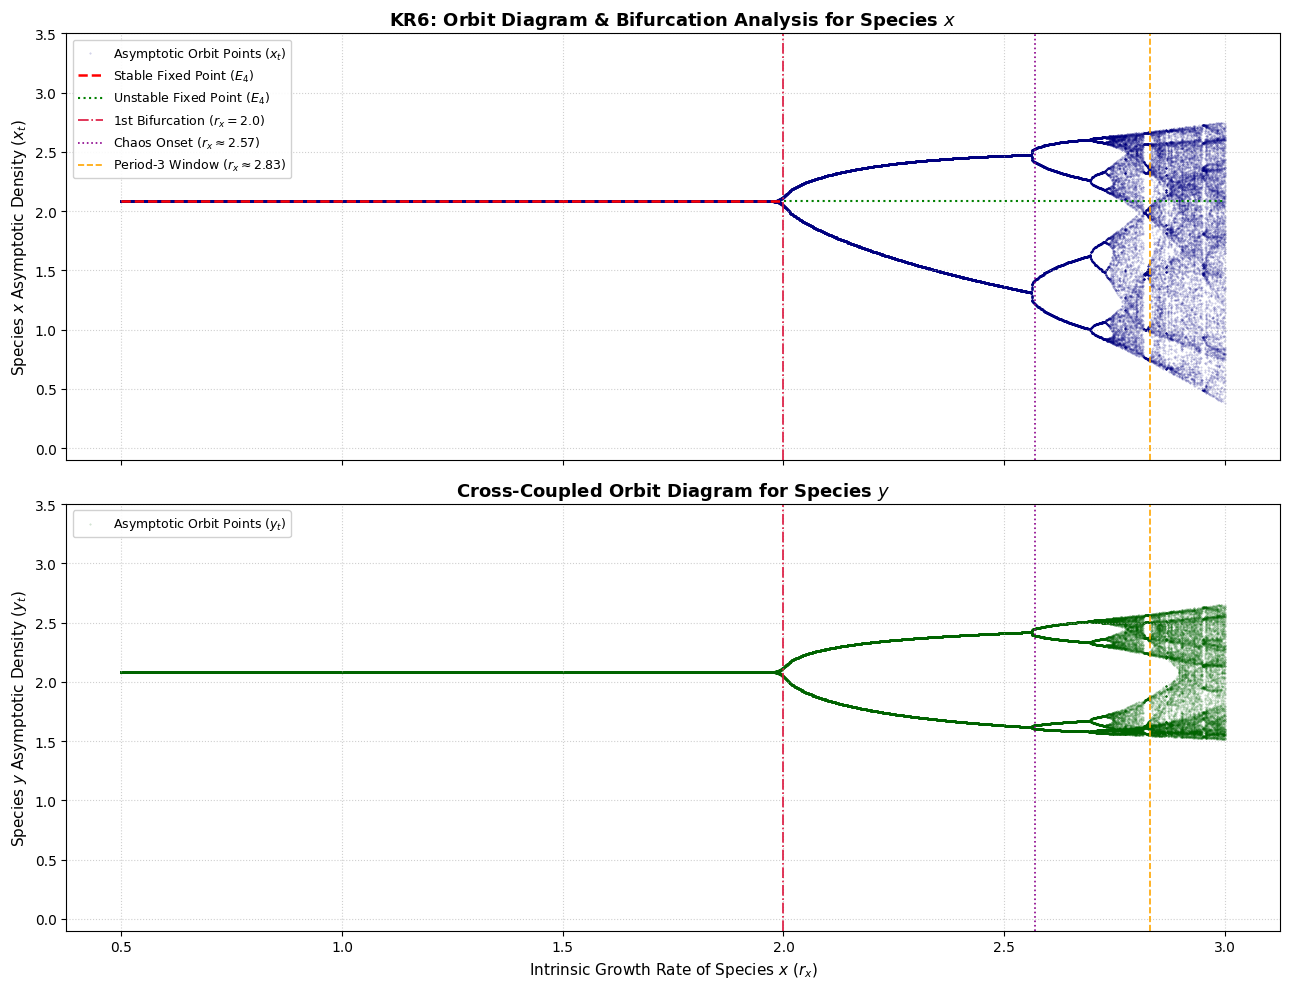

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_two_prey_orbit(a=0.2, b=0.2, ry=2.0, Kx=2.5, Ky=2.5, 
                            rx_min=0.5, rx_max=3.0, rx_steps=1000, 
                            transient_steps=300, sample_steps=150, 
                            x0=1.0, y0=0.8):
    """
    Generates data for the orbit/bifurcation diagram sweeping r_x from rx_min to rx_max.
    Returns rx_vals, x_orbits, y_orbits, and analytical fixed points.
    """
    rx_vals = np.linspace(rx_min, rx_max, rx_steps)
    
    rx_list = []
    x_orbit_list = []
    y_orbit_list = []
    
    # Store analytical fixed points for overlay
    x_fp_analytical = []
    
    for rx in rx_vals:
        x = x0
        y = y0
        
        # Transient phase (discard initial transient states)
        for _ in range(transient_steps):
            next_x = x + rx * x * (1.0 - (x + a * y) / Kx)
            next_y = y + ry * y * (1.0 - (y + b * x) / Ky)
            x, y = next_x, next_y
            
        # Sampling phase (collect asymptotic states)
        for _ in range(sample_steps):
            next_x = x + rx * x * (1.0 - (x + a * y) / Kx)
            next_y = y + ry * y * (1.0 - (y + b * x) / Ky)
            x, y = next_x, next_y
            
            # Check for numerical explosion/extinction
            if np.isnan(x) or x < 0 or x > 10:
                break
                
            rx_list.append(rx)
            x_orbit_list.append(x)
            y_orbit_list.append(y)
            
        # Analytical coexistence fixed point x_eq* = (Kx - a*Ky) / (1 - a*b)
        x_eq = (Kx - a * Ky) / (1.0 - a * b)
        x_fp_analytical.append(x_eq)
        
    return rx_vals, np.array(rx_list), np.array(x_orbit_list), np.array(y_orbit_list), np.array(x_fp_analytical)

def plot_bifurcation_orbit_diagram():
    a, b = 0.2, 0.2
    ry = 2.0
    Kx, Ky = 2.5, 2.5
    rx_min, rx_max = 0.5, 3.0
    
    rx_vals, rx_pts, x_pts, y_pts, x_fp_analytical = simulate_two_prey_orbit(
        a=a, b=b, ry=ry, Kx=Kx, Ky=Ky, 
        rx_min=rx_min, rx_max=rx_max, rx_steps=1200,
        transient_steps=300, sample_steps=150
    )
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 10), sharex=True)
    
    #--- Panel 1: Orbit Diagram for Species x with Bifurcation Overlay ---
    ax1.scatter(rx_pts, x_pts, s=0.15, c='navy', alpha=0.25, label='Asymptotic Orbit Points ($x_t$)')
    
    # Analytical fixed point line (stable up to rx = 2.0)
    ax1.plot(rx_vals[rx_vals <= 2.0], x_fp_analytical[:len(rx_vals[rx_vals <= 2.0])], 'r--', lw=1.8, label='Stable Fixed Point ($E_4$)')
    ax1.plot(rx_vals[rx_vals > 2.0], x_fp_analytical[len(rx_vals[rx_vals <= 2.0]):], 'g:', lw=1.5, label='Unstable Fixed Point ($E_4$)')
    
    # Critical Bifurcation Thresholds
    ax1.axvline(x=2.0, color='crimson', linestyle='-.', lw=1.2, label='1st Bifurcation ($r_x=2.0$)')
    ax1.axvline(x=2.57, color='darkmagenta', linestyle=':', lw=1.2, label='Chaos Onset ($r_x \\approx 2.57$)')
    ax1.axvline(x=2.83, color='orange', linestyle='--', lw=1.2, label='Period-3 Window ($r_x \\approx 2.83$)')
    
    ax1.set_title('KR6: Orbit Diagram & Bifurcation Analysis for Species $x$', fontsize=13, fontweight='bold')
    ax1.set_ylabel('Species $x$ Asymptotic Density ($x_t$)', fontsize=11)
    ax1.set_ylim(-0.1, 3.5)
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.legend(loc='upper left', framealpha=0.9, fontsize=9)

    # --- Panel 2: Orbit Diagram for Species y (Cross-Coupled Dynamics) ---
    ax2.scatter(rx_pts, y_pts, s=0.15, c='darkgreen', alpha=0.25, label='Asymptotic Orbit Points ($y_t$)')
    
    ax2.axvline(x=2.0, color='crimson', linestyle='-.', lw=1.2)
    ax2.axvline(x=2.57, color='darkmagenta', linestyle=':', lw=1.2)
    ax2.axvline(x=2.83, color='orange', linestyle='--', lw=1.2)
    
    ax2.set_title('Cross-Coupled Orbit Diagram for Species $y$', fontsize=13, fontweight='bold')
    ax2.set_xlabel('Intrinsic Growth Rate of Species $x$ ($r_x$)', fontsize=11)
    ax2.set_ylabel('Species $y$ Asymptotic Density ($y_t$)', fontsize=11)
    ax2.set_ylim(-0.1, 3.5)
    ax2.grid(True, linestyle=':', alpha=0.6)
    ax2.legend(loc='upper left', framealpha=0.9, fontsize=9)

    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    plot_bifurcation_orbit_diagram()
